In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")
print("libraries imported successfully")

libraries imported successfully


In [4]:
df=pd.read_csv("../data/bitcoin.csv")

In [5]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100


In [7]:
df.shape

(2713, 7)

In [12]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
df.sample(10)

,Date,Open,High,Low,Close,Adj Close,Volume
1297,2018-04-06,6815.959961,6857.490234,6575.000000,6636.319824,6636.319824,3766810112
2686,2022-01-24,36275.734375,37247.519531,33184.058594,36654.328125,36654.328125,41856658597
1652,2019-03-27,3984.244873,4087.066162,3977.810547,4087.066162,4087.066162,10897131934
312,2015-07-26,288.640015,293.052002,287.705994,292.686005,292.686005,16032300
850,2017-01-14,825.142029,835.085022,812.455994,818.411987,818.411987,93063296
303,2015-07-17,278.091003,280.279999,272.042999,279.471985,279.471985,27591400
2402,2021-04-15,63075.195313,63821.671875,62208.964844,63314.011719,63314.011719,60954381579
2085,2020-06-02,10162.973633,10182.340820,9460.571289,9529.803711,9529.803711,39137252109
1403,2018-07-21,7352.720215,7437.640137,7262.410156,7419.290039,7419.290039,3726609920
552,2016-03-22,413.131989,418.375000,412.531006,418.088989,418.088989,66813300


In [13]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2713.000000,2713.000000,2713.000000,2713.000000,2713.000000,2.713000e+03
mean,11311.041069,11614.292482,10975.555057,11323.914637,11323.914637,1.470462e+10
std,16106.428891,16537.390649,15608.572560,16110.365010,16110.365010,2.001627e+10
min,176.897003,211.731003,171.509995,178.102997,178.102997,5.914570e+06
25%,606.396973,609.260986,604.109985,606.718994,606.718994,7.991080e+07
50%,6301.569824,6434.617676,6214.220215,6317.609863,6317.609863,5.098183e+09
75%,10452.399414,10762.644531,10202.387695,10462.259766,10462.259766,2.456992e+10
max,67549.734375,68789.625000,66382.062500,67566.828125,67566.828125,3.509679e+11


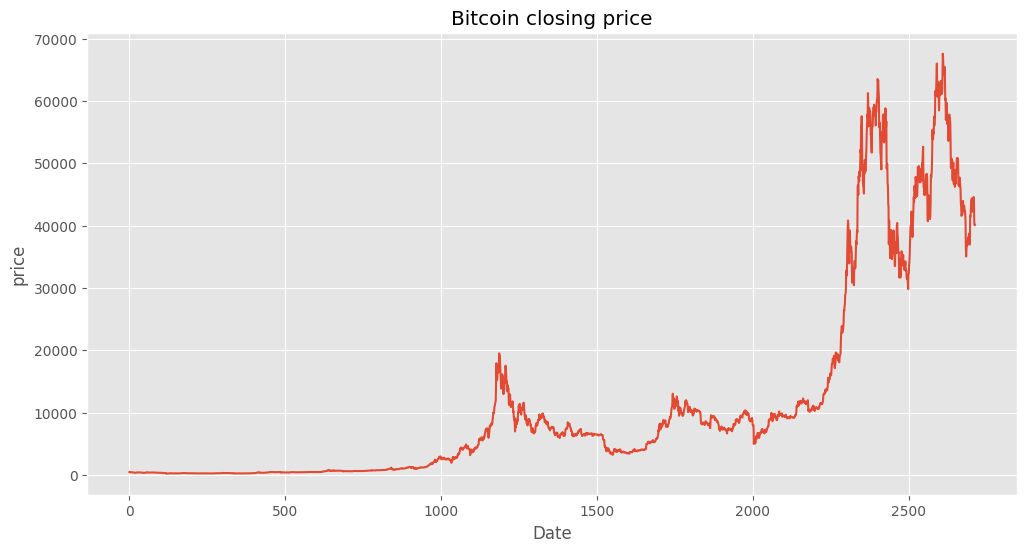

In [15]:
plt.figure(figsize=(12,6))
plt.plot(df["Close"])
plt.title("Bitcoin closing price")
plt.xlabel("Date")
plt.ylabel("price")
plt.show()

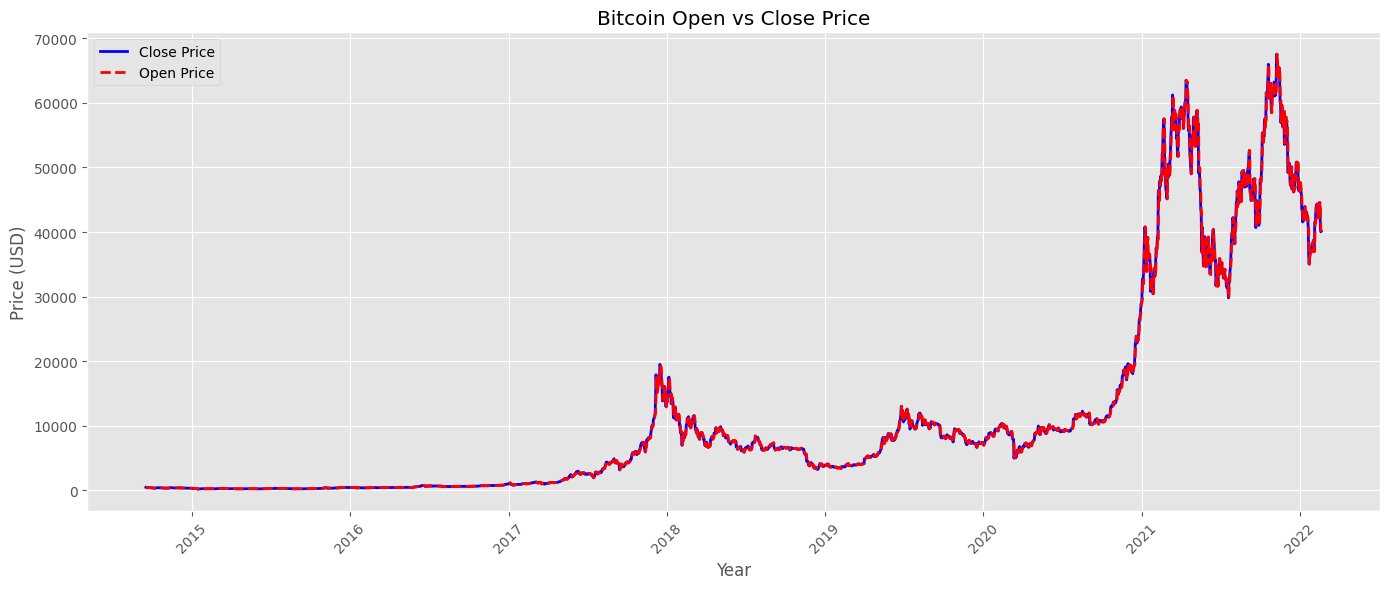

In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df['Date'] = pd.to_datetime(df['Date'])

fig, ax = plt.subplots(figsize=(14,6))

ax.plot(df['Date'], df['Close'],
        color='blue',
        linewidth=2,
        label='Close Price')

ax.plot(df['Date'], df['Open'],
        color='red',
        linestyle='--',
        linewidth=2,
        label='Open Price')

ax.xaxis.set_major_locator(mdates.YearLocator(1))      # Every year
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.xticks(rotation=45)

plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.title("Bitcoin Open vs Close Price")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [29]:
df[df['Close'] == df['Adj Close']].shape, df.shape


((2713, 7), (2713, 7))

In [30]:
df=df.drop(['Adj Close'], axis=1)

In [31]:
df.head()

,Date,Open,High,Low,Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100


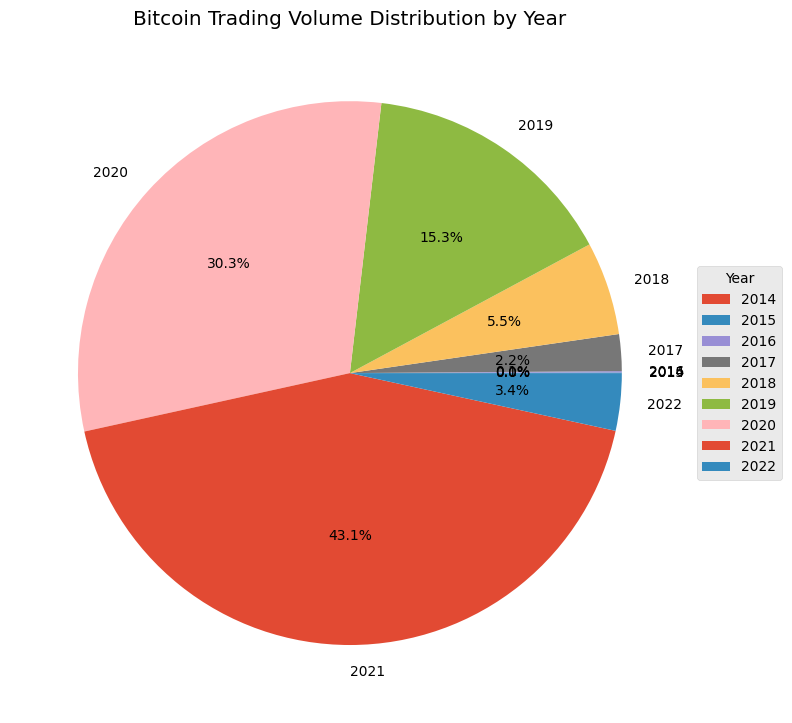

In [46]:
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

yearly_volume = df.groupby('Year')['Volume'].sum()
plt.figure(figsize=(8,8))

plt.pie(
    yearly_volume,
    labels=yearly_volume.index,
    autopct='%1.1f%%'
)

plt.title("Bitcoin Trading Volume Distribution by Year")

plt.legend(
    title="Year",
    loc="center left",
     bbox_to_anchor=(1, 0.5)
   
)

plt.tight_layout()
plt.show()


In [48]:
df.head()

,Date,Open,High,Low,Close,Volume,Year
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014
